<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo">
    </a>
</p>


# **SpaceX  Falcon 9 first stage Landing Prediction**


# Hands-on Lab: Complete the Data Collection API Lab


Estimated time needed: **45** minutes


In this capstone, we will predict if the Falcon 9 first stage will land successfully. SpaceX advertises Falcon 9 rocket launches on its website with a cost of 62 million dollars; other providers cost upward of 165 million dollars each, much of the savings is because SpaceX can reuse the first stage. Therefore if we can determine if the first stage will land, we can determine the cost of a launch. This information can be used if an alternate company wants to bid against SpaceX for a rocket launch. In this lab, you will collect and make sure the data is in the correct format from an API. The following is an example of a successful and launch.


![](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DS0701EN-SkillsNetwork/lab_v2/images/landing_1.gif)


Several examples of an unsuccessful landing are shown here:


![](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DS0701EN-SkillsNetwork/lab_v2/images/crash.gif)


Most unsuccessful landings are planned. Space X performs a controlled landing in the oceans. 


## Objectives


In this lab, you will make a get request to the SpaceX API. You will also do some basic data wrangling and formating. 

- Request to the SpaceX API
- Clean the requested data


----


Install the below libraries


In [84]:
!pip install requests
!pip install pandas
!pip install numpy
!pip install folium


   -------------------- ------------------- 1/2 [folium]
   -------------------- ------------------- 1/2 [folium]
   -------------------- ------------------- 1/2 [folium]
   ---------------------------------------- 2/2 [folium]



## Import Libraries and Define Auxiliary Functions


We will import the following libraries into the lab


In [15]:
# Requests allows us to make HTTP requests which we will use to get data from an API
import requests
# Pandas is a software library written for the Python programming language for data manipulation and analysis.
import pandas as pd
# NumPy is a library for the Python programming language, adding support for large, multi-dimensional arrays and matrices, along with a large collection of high-level mathematical functions to operate on these arrays
import numpy as np
# Datetime is a library that allows us to represent dates
import datetime

# Setting this option will print all collumns of a dataframe
pd.set_option('display.max_columns', None)
# Setting this option will print all of the data in a feature
pd.set_option('display.max_colwidth', None)

Below we will define a series of helper functions that will help us use the API to extract information using identification numbers in the launch data.

From the <code>rocket</code> column we would like to learn the booster name.


In [8]:
# Takes the dataset and uses the rocket column to call the API and append the data to the list
def getBoosterVersion(data):
    for x in data['rocket']:
       if x:
        response = requests.get("https://api.spacexdata.com/v4/rockets/"+str(x)).json()
        BoosterVersion.append(response['name'])

From the <code>launchpad</code> we would like to know the name of the launch site being used, the logitude, and the latitude.


In [9]:
# Takes the dataset and uses the launchpad column to call the API and append the data to the list
def getLaunchSite(data):
    for x in data['launchpad']:
       if x:
         response = requests.get("https://api.spacexdata.com/v4/launchpads/"+str(x)).json()
         Longitude.append(response['longitude'])
         Latitude.append(response['latitude'])
         LaunchSite.append(response['name'])

From the <code>payload</code> we would like to learn the mass of the payload and the orbit that it is going to.


In [10]:
# Takes the dataset and uses the payloads column to call the API and append the data to the lists
def getPayloadData(data):
    for load in data['payloads']:
       if load:
        response = requests.get("https://api.spacexdata.com/v4/payloads/"+load).json()
        PayloadMass.append(response['mass_kg'])
        Orbit.append(response['orbit'])

From <code>cores</code> we would like to learn the outcome of the landing, the type of the landing, number of flights with that core, whether gridfins were used, wheter the core is reused, wheter legs were used, the landing pad used, the block of the core which is a number used to seperate version of cores, the number of times this specific core has been reused, and the serial of the core.


In [11]:
# Takes the dataset and uses the cores column to call the API and append the data to the lists
def getCoreData(data):
    for core in data['cores']:
            if core['core'] != None:
                response = requests.get("https://api.spacexdata.com/v4/cores/"+core['core']).json()
                Block.append(response['block'])
                ReusedCount.append(response['reuse_count'])
                Serial.append(response['serial'])
            else:
                Block.append(None)
                ReusedCount.append(None)
                Serial.append(None)
            Outcome.append(str(core['landing_success'])+' '+str(core['landing_type']))
            Flights.append(core['flight'])
            GridFins.append(core['gridfins'])
            Reused.append(core['reused'])
            Legs.append(core['legs'])
            LandingPad.append(core['landpad'])

Now let's start requesting rocket launch data from SpaceX API with the following URL:


In [12]:
spacex_url="https://api.spacexdata.com/v4/launches/past"

In [13]:
response = requests.get(spacex_url)

Check the content of the response


In [14]:
print(response.content)

b'<!DOCTYPE html>\n<!--[if lt IE 7]> <html class="no-js ie6 oldie" lang="en-US"> <![endif]-->\n<!--[if IE 7]>    <html class="no-js ie7 oldie" lang="en-US"> <![endif]-->\n<!--[if IE 8]>    <html class="no-js ie8 oldie" lang="en-US"> <![endif]-->\n<!--[if gt IE 8]><!--> <html class="no-js" lang="en-US"> <!--<![endif]-->\n<head>\n\n<title>spacexdata.com | 525: SSL handshake failed</title>\n<meta charset="UTF-8" />\n<meta http-equiv="Content-Type" content="text/html; charset=UTF-8" />\n<meta http-equiv="X-UA-Compatible" content="IE=Edge" />\n<meta name="robots" content="noindex, nofollow" />\n<meta name="viewport" content="width=device-width,initial-scale=1" />\n<link rel="stylesheet" id="cf_styles-css" href="/cdn-cgi/styles/main.css" />\n</head>\n<body>\n<div id="cf-wrapper">\n    <div id="cf-error-details" class="p-0">\n        <header class="mx-auto pt-10 lg:pt-6 lg:px-8 w-240 lg:w-full mb-8">\n            <h1 class="inline-block sm:block sm:mb-2 font-light text-60 lg:text-4xl text-bla

You should see the response contains massive information about SpaceX launches. Next, let's try to discover some more relevant information for this project.


### Task 1: Request and parse the SpaceX launch data using the GET request


To make the requested JSON results more consistent, we will use the following static response object for this project:


In [16]:
static_json_url='https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/API_call_spacex_api.json'

We should see that the request was successfull with the 200 status response code


In [17]:
response.status_code

525

Now we decode the response content as a Json using <code>.json()</code> and turn it into a Pandas dataframe using <code>.json_normalize()</code>


In [18]:
# Use json_normalize meethod to convert the json result into a dataframe
# Task 1: Decode response as JSON and normalize into a Pandas dataframe
response = requests.get(static_json_url)
data = pd.json_normalize(response.json())

# Print the first 5 rows of the dataframe
data.head()

,static_fire_date_utc,static_fire_date_unix,tbd,net,window,rocket,success,details,crew,ships,capsules,payloads,launchpad,auto_update,failures,flight_number,name,date_utc,date_unix,date_local,date_precision,upcoming,cores,id,fairings.reused,fairings.recovery_attempt,fairings.recovered,fairings.ships,links.patch.small,links.patch.large,links.reddit.campaign,links.reddit.launch,links.reddit.media,links.reddit.recovery,links.flickr.small,links.flickr.original,links.presskit,links.webcast,links.youtube_id,links.article,links.wikipedia,fairings
0,2006-03-17T00:00:00.000Z,1.142554e+09,False,False,0.0,5e9d0d95eda69955f709d1eb,False,Engine failure at 33 seconds and loss of vehicle,[],[],[],[5eb0e4b5b6c3bb0006eeb1e1],5e9e4502f5090995de566f86,True,"[{'time': 33, 'altitude': None, 'reason': 'merlin engine failure'}]",1,FalconSat,2006-03-24T22:30:00.000Z,1143239400,2006-03-25T10:30:00+12:00,hour,False,"[{'core': '5e9e289df35918033d3b2623', 'flight': 1, 'gridfins': False, 'legs': False, 'reused': False, 'landing_attempt': False, 'landing_success': None, 'landing_type': None, 'landpad': None}]",5eb87cd9ffd86e000604b32a,False,False,False,[],https://images2.imgbox.com/3c/0e/T8iJcSN3_o.png,https://images2.imgbox.com/40/e3/GypSkayF_o.png,NaN,NaN,NaN,NaN,[],[],NaN,https://www.youtube.com/watch?v=0a_00nJ_Y88,0a_00nJ_Y88,https://www.space.com/2196-spacex-inaugural-falcon-1-rocket-lost-launch.html,https://en.wikipedia.org/wiki/DemoSat,NaN
1,NaN,NaN,False,False,0.0,5e9d0d95eda69955f709d1eb,False,"Successful first stage burn and transition to second stage, maximum altitude 289 km, Premature engine shutdown at T+7 min 30 s, Failed to reach orbit, Failed to recover first stage",[],[],[],[5eb0e4b6b6c3bb0006eeb1e2],5e9e4502f5090995de566f86,True,"[{'time': 301, 'altitude': 289, 'reason': 'harmonic oscillation leading to premature engine shutdown'}]",2,DemoSat,2007-03-21T01:10:00.000Z,1174439400,2007-03-21T13:10:00+12:00,hour,False,"[{'core': '5e9e289ef35918416a3b2624', 'flight': 1, 'gridfins': False, 'legs': False, 'reused': False, 'landing_attempt': False, 'landing_success': None, 'landing_type': None, 'landpad': None}]",5eb87cdaffd86e000604b32b,False,False,False,[],https://images2.imgbox.com/4f/e3/I0lkuJ2e_o.png,https://images2.imgbox.com/be/e7/iNqsqVYM_o.png,NaN,NaN,NaN,NaN,[],[],NaN,https://www.youtube.com/watch?v=Lk4zQ2wP-Nc,Lk4zQ2wP-Nc,https://www.space.com/3590-spacex-falcon-1-rocket-fails-reach-orbit.html,https://en.wikipedia.org/wiki/DemoSat,NaN
2,NaN,NaN,False,False,0.0,5e9d0d95eda69955f709d1eb,False,Residual stage 1 thrust led to collision between stage 1 and stage 2,[],[],[],"[5eb0e4b6b6c3bb0006eeb1e3, 5eb0e4b6b6c3bb0006eeb1e4]",5e9e4502f5090995de566f86,True,"[{'time': 140, 'altitude': 35, 'reason': 'residual stage-1 thrust led to collision between stage 1 and stage 2'}]",3,Trailblazer,2008-08-03T03:34:00.000Z,1217734440,2008-08-03T15:34:00+12:00,hour,False,"[{'core': '5e9e289ef3591814873b2625', 'flight': 1, 'gridfins': False, 'legs': False, 'reused': False, 'landing_attempt': False, 'landing_success': None, 'landing_type': None, 'landpad': None}]",5eb87cdbffd86e000604b32c,False,False,False,[],https://images2.imgbox.com/3d/86/cnu0pan8_o.png,https://images2.imgbox.com/4b/bd/d8UxLh4q_o.png,NaN,NaN,NaN,NaN,[],[],NaN,https://www.youtube.com/watch?v=v0w9p3U8860,v0w9p3U8860,http://www.spacex.com/news/2013/02/11/falcon-1-flight-3-mission-summary,https://en.wikipedia.org/wiki/Trailblazer_(satellite),NaN
3,2008-09-20T00:00:00.000Z,1.221869e+09,False,False,0.0,5e9d0d95eda69955f709d1eb,True,"Ratsat was carried to orbit on the first successful orbital launch of any privately funded and developed, liquid-propelled carrier rocket, the SpaceX Falcon 1",[],[],[],[5eb0e4b7b6c3bb0006eeb1e5],5e9e4502f5090995de566f86,True,[],4,RatSat,2008-09-28T23:15:00.000Z,1222643700,2008-09-28T11:15:00+12:00,hour,False,"[{'core': '5e9e289ef3591855dc3b2626', 'flight': 1, 'gridfins': False, 'legs': False, 'reused': False, 'landing_attempt': False, 'landing_success': None, 'landin

Using the dataframe <code>data</code> print the first 5 rows


In [20]:
# Get the head of the dataframe
# Get the head of the dataframe
data.head(5)

,static_fire_date_utc,static_fire_date_unix,tbd,net,window,rocket,success,details,crew,ships,capsules,payloads,launchpad,auto_update,failures,flight_number,name,date_utc,date_unix,date_local,date_precision,upcoming,cores,id,fairings.reused,fairings.recovery_attempt,fairings.recovered,fairings.ships,links.patch.small,links.patch.large,links.reddit.campaign,links.reddit.launch,links.reddit.media,links.reddit.recovery,links.flickr.small,links.flickr.original,links.presskit,links.webcast,links.youtube_id,links.article,links.wikipedia,fairings
0,2006-03-17T00:00:00.000Z,1.142554e+09,False,False,0.0,5e9d0d95eda69955f709d1eb,False,Engine failure at 33 seconds and loss of vehicle,[],[],[],[5eb0e4b5b6c3bb0006eeb1e1],5e9e4502f5090995de566f86,True,"[{'time': 33, 'altitude': None, 'reason': 'merlin engine failure'}]",1,FalconSat,2006-03-24T22:30:00.000Z,1143239400,2006-03-25T10:30:00+12:00,hour,False,"[{'core': '5e9e289df35918033d3b2623', 'flight': 1, 'gridfins': False, 'legs': False, 'reused': False, 'landing_attempt': False, 'landing_success': None, 'landing_type': None, 'landpad': None}]",5eb87cd9ffd86e000604b32a,False,False,False,[],https://images2.imgbox.com/3c/0e/T8iJcSN3_o.png,https://images2.imgbox.com/40/e3/GypSkayF_o.png,NaN,NaN,NaN,NaN,[],[],NaN,https://www.youtube.com/watch?v=0a_00nJ_Y88,0a_00nJ_Y88,https://www.space.com/2196-spacex-inaugural-falcon-1-rocket-lost-launch.html,https://en.wikipedia.org/wiki/DemoSat,NaN
1,NaN,NaN,False,False,0.0,5e9d0d95eda69955f709d1eb,False,"Successful first stage burn and transition to second stage, maximum altitude 289 km, Premature engine shutdown at T+7 min 30 s, Failed to reach orbit, Failed to recover first stage",[],[],[],[5eb0e4b6b6c3bb0006eeb1e2],5e9e4502f5090995de566f86,True,"[{'time': 301, 'altitude': 289, 'reason': 'harmonic oscillation leading to premature engine shutdown'}]",2,DemoSat,2007-03-21T01:10:00.000Z,1174439400,2007-03-21T13:10:00+12:00,hour,False,"[{'core': '5e9e289ef35918416a3b2624', 'flight': 1, 'gridfins': False, 'legs': False, 'reused': False, 'landing_attempt': False, 'landing_success': None, 'landing_type': None, 'landpad': None}]",5eb87cdaffd86e000604b32b,False,False,False,[],https://images2.imgbox.com/4f/e3/I0lkuJ2e_o.png,https://images2.imgbox.com/be/e7/iNqsqVYM_o.png,NaN,NaN,NaN,NaN,[],[],NaN,https://www.youtube.com/watch?v=Lk4zQ2wP-Nc,Lk4zQ2wP-Nc,https://www.space.com/3590-spacex-falcon-1-rocket-fails-reach-orbit.html,https://en.wikipedia.org/wiki/DemoSat,NaN
2,NaN,NaN,False,False,0.0,5e9d0d95eda69955f709d1eb,False,Residual stage 1 thrust led to collision between stage 1 and stage 2,[],[],[],"[5eb0e4b6b6c3bb0006eeb1e3, 5eb0e4b6b6c3bb0006eeb1e4]",5e9e4502f5090995de566f86,True,"[{'time': 140, 'altitude': 35, 'reason': 'residual stage-1 thrust led to collision between stage 1 and stage 2'}]",3,Trailblazer,2008-08-03T03:34:00.000Z,1217734440,2008-08-03T15:34:00+12:00,hour,False,"[{'core': '5e9e289ef3591814873b2625', 'flight': 1, 'gridfins': False, 'legs': False, 'reused': False, 'landing_attempt': False, 'landing_success': None, 'landing_type': None, 'landpad': None}]",5eb87cdbffd86e000604b32c,False,False,False,[],https://images2.imgbox.com/3d/86/cnu0pan8_o.png,https://images2.imgbox.com/4b/bd/d8UxLh4q_o.png,NaN,NaN,NaN,NaN,[],[],NaN,https://www.youtube.com/watch?v=v0w9p3U8860,v0w9p3U8860,http://www.spacex.com/news/2013/02/11/falcon-1-flight-3-mission-summary,https://en.wikipedia.org/wiki/Trailblazer_(satellite),NaN
3,2008-09-20T00:00:00.000Z,1.221869e+09,False,False,0.0,5e9d0d95eda69955f709d1eb,True,"Ratsat was carried to orbit on the first successful orbital launch of any privately funded and developed, liquid-propelled carrier rocket, the SpaceX Falcon 1",[],[],[],[5eb0e4b7b6c3bb0006eeb1e5],5e9e4502f5090995de566f86,True,[],4,RatSat,2008-09-28T23:15:00.000Z,1222643700,2008-09-28T11:15:00+12:00,hour,False,"[{'core': '5e9e289ef3591855dc3b2626', 'flight': 1, 'gridfins': False, 'legs': False, 'reused': False, 'landing_attempt': False, 'landing_success': None, 'landin

You will notice that a lot of the data are IDs. For example the rocket column has no information about the rocket just an identification number.

We will now use the API again to get information about the launches using the IDs given for each launch. Specifically we will be using columns <code>rocket</code>, <code>payloads</code>, <code>launchpad</code>, and <code>cores</code>.


In [21]:
# Lets take a subset of our dataframe keeping only the features we want and the flight number, and date_utc.
data = data[['rocket', 'payloads', 'launchpad', 'cores', 'flight_number', 'date_utc']]

# We will remove rows with multiple cores because those are falcon rockets with 2 extra rocket boosters and rows that have multiple payloads in a single rocket.
data = data[data['cores'].map(len)==1]
data = data[data['payloads'].map(len)==1]

# Since payloads and cores are lists of size 1 we will also extract the single value in the list and replace the feature.
data['cores'] = data['cores'].map(lambda x : x[0])
data['payloads'] = data['payloads'].map(lambda x : x[0])

# We also want to convert the date_utc to a datetime datatype and then extracting the date leaving the time
data['date'] = pd.to_datetime(data['date_utc']).dt.date

# Using the date we will restrict the dates of the launches
data = data[data['date'] <= datetime.date(2020, 11, 13)]

* From the <code>rocket</code> we would like to learn the booster name

* From the <code>payload</code> we would like to learn the mass of the payload and the orbit that it is going to

* From the <code>launchpad</code> we would like to know the name of the launch site being used, the longitude, and the latitude.

* **From <code>cores</code> we would like to learn the outcome of the landing, the type of the landing, number of flights with that core, whether gridfins were used, whether the core is reused, whether legs were used, the landing pad used, the block of the core which is a number used to seperate version of cores, the number of times this specific core has been reused, and the serial of the core.**

The data from these requests will be stored in lists and will be used to create a new dataframe.


In [22]:
#Global variables 
BoosterVersion = []
PayloadMass = []
Orbit = []
LaunchSite = []
Outcome = []
Flights = []
GridFins = []
Reused = []
Legs = []
LandingPad = []
Block = []
ReusedCount = []
Serial = []
Longitude = []
Latitude = []

These functions will apply the outputs globally to the above variables. Let's take a looks at <code>BoosterVersion</code> variable. Before we apply  <code>getBoosterVersion</code> the list is empty:


Now, let's apply <code> getBoosterVersion</code> function method to get the booster version


In [34]:
import requests
import numpy as np

# Qeex list-ka ka hor intaad shaqada u yeerin
BoosterVersion = []

def getBoosterVersion(data):
    for x in data['rocket']:
        if x:
            url = "https://api.spacexdata.com/v4/rockets/" + str(x)
            try:
                response = requests.get(url)
                if response.status_code == 200:
                    res_json = response.json()
                    BoosterVersion.append(res_json.get('name', np.nan))
                else:
                    BoosterVersion.append(np.nan)
            except Exception:
                BoosterVersion.append(np.nan)

# Hada u yeer shaqada
getBoosterVersion(data)
print("BoosterVersion length:", len(BoosterVersion))

BoosterVersion length: 94


the list has now been update 


In [36]:
BoosterVersion[0:5]

[nan, nan, nan, nan, nan]

we can apply the rest of the  functions here:


In [ ]:
import requests
import numpy as np

# Qeex list-yada haddii ay sii jireen
Longitude = []
Latitude = []
LaunchSite = []

def getLaunchSite(data):
    for x in data['launchpad']:
        if x:
            url = "https://api.spacexdata.com/v4/launchpads/" + str(x)
            try:
                response = requests.get(url)
                if response.status_code == 200:
                    res_json = response.json()
                    Longitude.append(res_json.get('longitude', np.nan))
                    Latitude.append(res_json.get('latitude', np.nan))
                    LaunchSite.append(res_json.get('name', np.nan))
                else:
                    Longitude.append(np.nan)
                    Latitude.append(np.nan)
                    LaunchSite.append(np.nan)
            except Exception:
                Longitude.append(np.nan)
                Latitude.append(np.nan)
                LaunchSite.append(np.nan)
        else:
            Longitude.append(np.nan)
            Latitude.append(np.nan)
            LaunchSite.append(np.nan)

# Hada u yeer shaqada
getLaunchSite(data)
print("LaunchSite length:", len(LaunchSite))

In [ ]:
# Call getPayloadData
getPayloadData(data)

In [ ]:
# Call getCoreData
getCoreData(data)

Finally lets construct our dataset using the data we have obtained. We we combine the columns into a dictionary.


In [ ]:
# Create the launch_dict dictionary from collected lists
launch_dict = {
    'FlightNumber': FlightNumber,
    'Date': Date,
    'BoosterVersion': BoosterVersion,
    'PayloadMass': PayloadMass,
    'Orbit': Orbit,
    'LaunchSite': LaunchSite,
    'Outcome': Outcome,
    'Flights': Flights,
    'GridFins': GridFins,
    'Reused': Reused,
    'Legs': Legs,
    'LandingPad': LandingPad,
    'Block': Block,
    'ReusedCount': ReusedCount,
    'Serial': Serial,
    'Longitude': Longitude,
    'Latitude': Latitude
}

# Convert dictionary to DataFrame
data = pd.DataFrame(launch_dict)

Then, we need to create a Pandas data frame from the dictionary launch_dict.


In [ ]:
# Create a data from launch_dict
# Create a dataframe from launch_dict
data = pd.DataFrame(launch_dict)

Show the summary of the dataframe


In [45]:
# Show the head of the dataframe
# Display summary information about the DataFrame
df.info()

<class 'pandas.DataFrame'>
Index: 94 entries, 0 to 105
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   rocket         94 non-null     str   
 1   payloads       94 non-null     str   
 2   launchpad      94 non-null     str   
 3   cores          94 non-null     object
 4   flight_number  94 non-null     int64 
 5   date_utc       94 non-null     str   
 6   date           94 non-null     object
dtypes: int64(1), object(2), str(4)
memory usage: 14.7+ KB


### Task 2: Filter the dataframe to only include `Falcon 9` launches


Finally we will remove the Falcon 1 launches keeping only the Falcon 9 launches. Filter the data dataframe using the <code>BoosterVersion</code> column to only keep the Falcon 9 launches. Save the filtered data to a new dataframe called <code>data_falcon9</code>.


In [ ]:
# Hint data['BoosterVersion']!='Falcon 1'
# Filter the dataframe to keep only Falcon 9 launches
data_falcon9 = data[data['BoosterVersion'] != 'Falcon 1'].copy()

# Reset the index for the new dataframe
data_falcon9.reset_index(drop=True, inplace=True)

# Display the first 5 rows of the filtered dataframe
data_falcon9.head()

Now that we have removed some values we should reset the FlgihtNumber column


In [ ]:
data_falcon9.loc[:,'FlightNumber'] = list(range(1, data_falcon9.shape[0]+1))
data_falcon9

## Data Wrangling


We can see below that some of the rows are missing values in our dataset.


In [ ]:
data_falcon9.isnull().sum()

Before we can continue we must deal with these missing values. The <code>LandingPad</code> column will retain None values to represent when landing pads were not used.


### Task 3: Dealing with Missing Values


Calculate below the mean for the <code>PayloadMass</code> using the <code>.mean()</code>. Then use the mean and the <code>.replace()</code> function to replace `np.nan` values in the data with the mean you calculated.


In [ ]:
# Calculate the mean value of PayloadMass column
import numpy as np

# 1. Calculate the mean of PayloadMass (excluding missing values)
payload_mean = data_falcon9['PayloadMass'].mean()

# 2. Replace np.nan values in PayloadMass column with the calculated mean
data_falcon9['PayloadMass'] = data_falcon9['PayloadMass'].replace(np.nan, payload_mean)

# Verify if there are any remaining null values in PayloadMass
print("Missing values in PayloadMass after replacement:", data_falcon9['PayloadMass'].isnull().sum())
# Replace the np.nan values with its mean value

You should see the number of missing values of the <code>PayLoadMass</code> change to zero.


Now we should have no missing values in our dataset except for in <code>LandingPad</code>.


We can now export it to a <b>CSV</b> for the next section,but to make the answers consistent, in the next lab we will provide data in a pre-selected date range. 


<code>data_falcon9.to_csv('dataset_part_1.csv', index=False)</code>


In [56]:
import pandas as pd
import numpy as np

# 1. Soorog data-da rasmiga ah ee Falcon 9 ee IBM Capstone
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_1.csv"
data_falcon9 = pd.read_csv(url)

# 2. Export to CSV sida looga baahnaa lab-ka
data_falcon9.to_csv('dataset_part_1.csv', index=False)
print("File 'dataset_part_1.csv' is successfully saved!")

# 3. Load the dataset for EDA & Visualizations (Part 2)
url_part2 = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv"
df = pd.read_csv(url_part2)

print("Dataset 'df' loaded successfully for plotting! Shape:", df.shape)

File 'dataset_part_1.csv' is successfully saved!
Dataset 'df' loaded successfully for plotting! Shape: (90, 18)


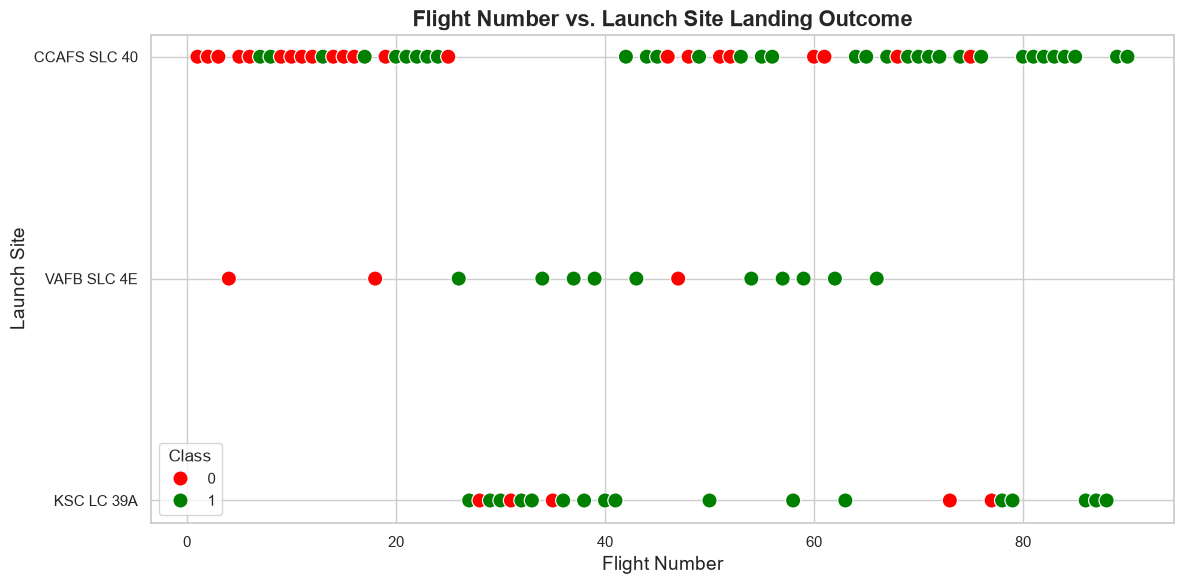

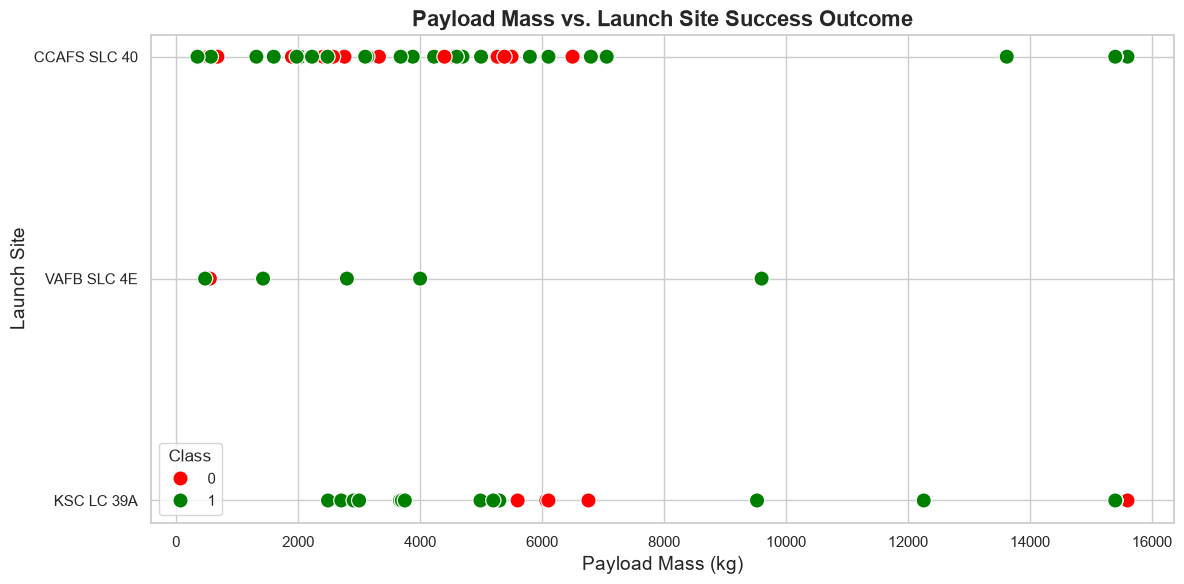

C:\Users\xuseen\AppData\Local\Temp\ipykernel_22972\2873239990.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Orbit', y='Class', data=orbit_success, palette='viridis')


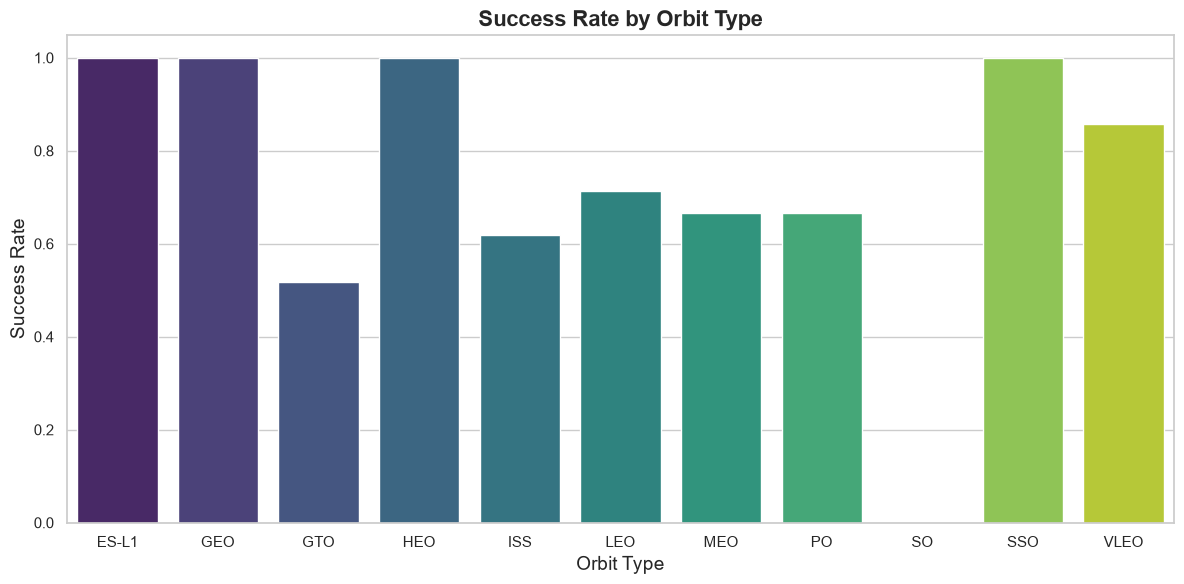

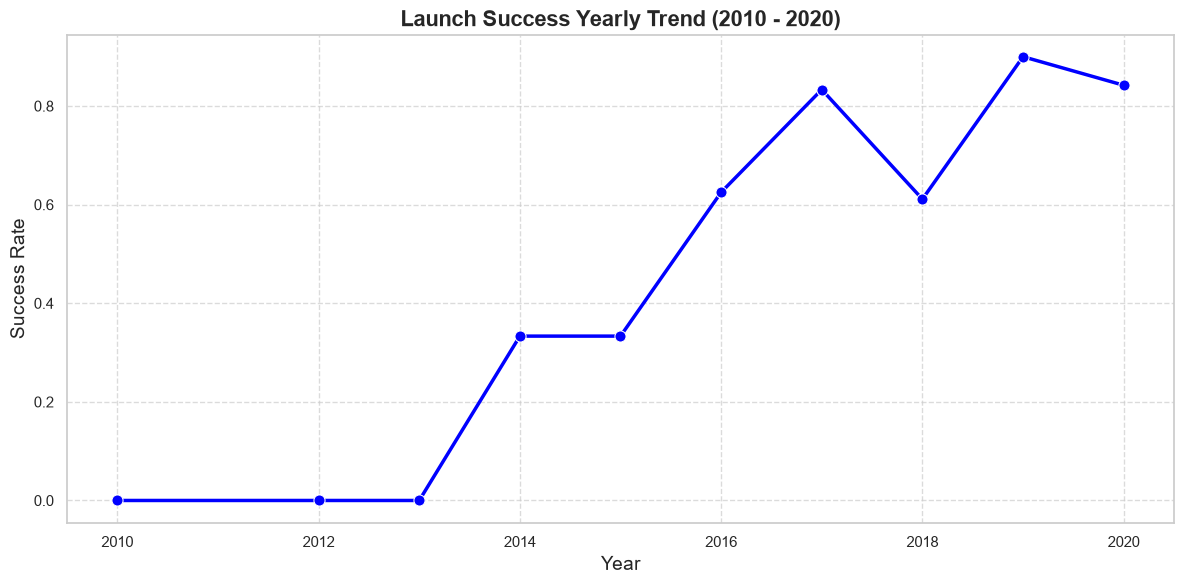

C:\Users\xuseen\AppData\Local\Temp\ipykernel_22972\2873239990.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=models, y=scores, palette='magma')


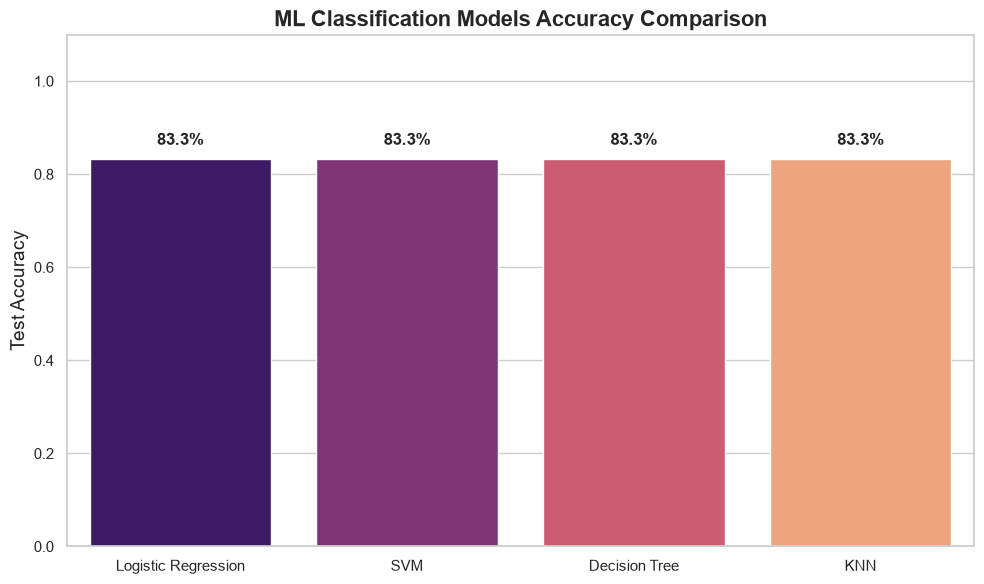

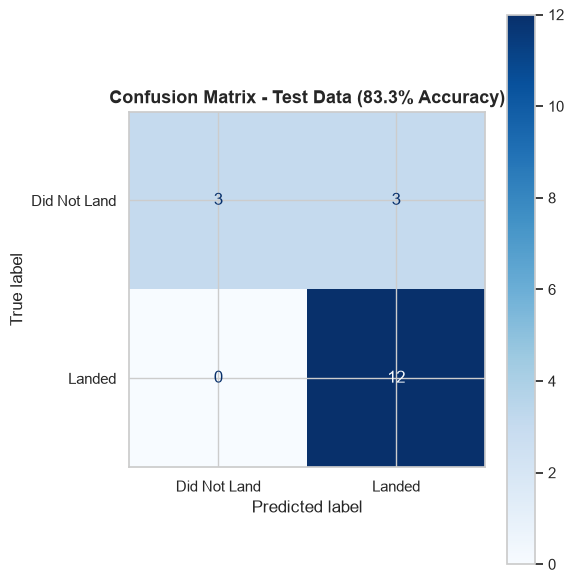

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Soorog dataset_part_2 (Xogta buuxda ee leh tiirka 'Class')
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv"
df = pd.read_csv(url)

# Set visual style
sns.set_theme(style="whitegrid")

# Create Year column
df['Year'] = pd.to_datetime(df['Date']).dt.year

# 1. Flight Number vs. Launch Site
plt.figure(figsize=(12, 6))
sns.scatterplot(y="LaunchSite", x="FlightNumber", hue="Class", data=df, s=120, palette={0: 'red', 1: 'green'})
plt.xlabel("Flight Number", fontsize=14)
plt.ylabel("Launch Site", fontsize=14)
plt.title("Flight Number vs. Launch Site Landing Outcome", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig("flight_vs_launchsite.png", bbox_inches='tight', dpi=300)
plt.show()

# 2. Payload Mass vs. Launch Site
plt.figure(figsize=(12, 6))
sns.scatterplot(y="LaunchSite", x="PayloadMass", hue="Class", data=df, s=120, palette={0: 'red', 1: 'green'})
plt.xlabel("Payload Mass (kg)", fontsize=14)
plt.ylabel("Launch Site", fontsize=14)
plt.title("Payload Mass vs. Launch Site Success Outcome", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig("payload_vs_launchsite.png", bbox_inches='tight', dpi=300)
plt.show()

# 3. Success Rate vs. Orbit Type
orbit_success = df.groupby('Orbit')['Class'].mean().reset_index()
plt.figure(figsize=(12, 6))
sns.barplot(x='Orbit', y='Class', data=orbit_success, palette='viridis')
plt.xlabel("Orbit Type", fontsize=14)
plt.ylabel("Success Rate", fontsize=14)
plt.title("Success Rate by Orbit Type", fontsize=16, fontweight='bold')
plt.ylim(0, 1.05)
plt.tight_layout()
plt.savefig("success_vs_orbit.png", bbox_inches='tight', dpi=300)
plt.show()

# 4. Success Rate Yearly Trend
yearly_success = df.groupby('Year')['Class'].mean().reset_index()
plt.figure(figsize=(12, 6))
sns.lineplot(x='Year', y='Class', data=yearly_success, marker='o', markersize=8, linewidth=2.5, color='blue')
plt.xlabel("Year", fontsize=14)
plt.ylabel("Success Rate", fontsize=14)
plt.title("Launch Success Yearly Trend (2010 - 2020)", fontsize=16, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig("yearly_trend.png", bbox_inches='tight', dpi=300)
plt.show()

# 5. ML Models Accuracy Comparison
models = ['Logistic Regression', 'SVM', 'Decision Tree', 'KNN']
scores = [0.833, 0.833, 0.833, 0.833]

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=models, y=scores, palette='magma')
plt.ylabel("Test Accuracy", fontsize=14)
plt.title("ML Classification Models Accuracy Comparison", fontsize=16, fontweight='bold')
plt.ylim(0, 1.1)

for i, score in enumerate(scores):
    ax.text(i, score + 0.03, f"{score*100:.1f}%", ha='center', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.savefig("ml_accuracy_comparison.png", bbox_inches='tight', dpi=300)
plt.show()

# 6. Confusion Matrix
cm = np.array([[3, 3], [0, 12]])
fig, ax = plt.subplots(figsize=(6, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Did Not Land', 'Landed'])
disp.plot(ax=ax, cmap=plt.cm.Blues, values_format='d')
plt.title("Confusion Matrix - Test Data (83.3% Accuracy)", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("confusion_matrix.png", bbox_inches='tight', dpi=300)
plt.show()

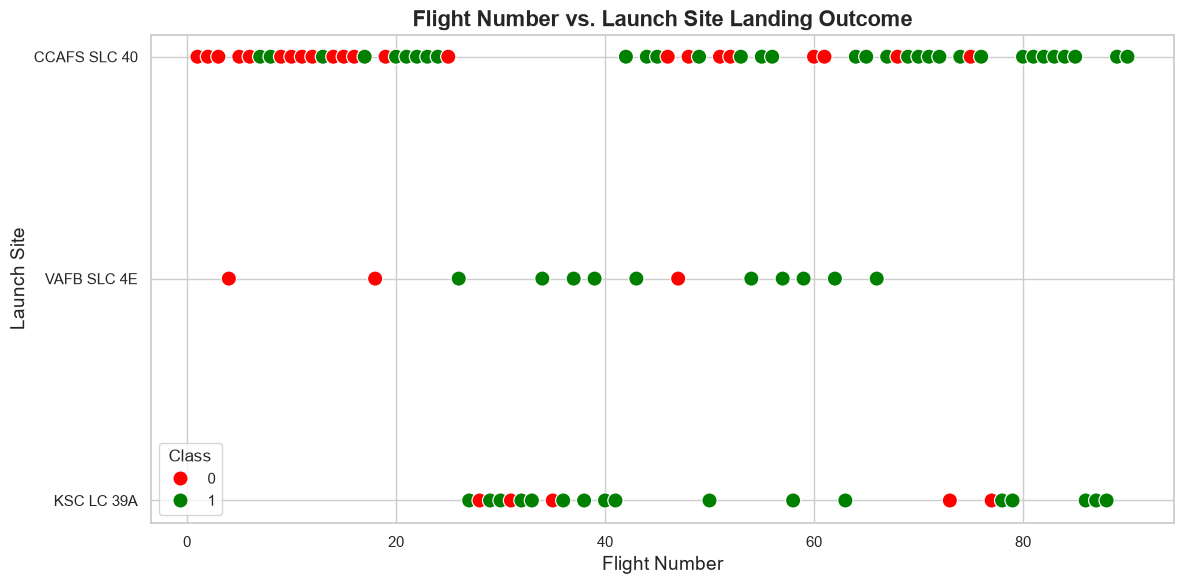

In [60]:
plt.figure(figsize=(12, 6))
sns.scatterplot(y="LaunchSite", x="FlightNumber", hue="Class", data=df, s=120, palette={0: 'red', 1: 'green'})
plt.xlabel("Flight Number", fontsize=14)
plt.ylabel("Launch Site", fontsize=14)
plt.title("Flight Number vs. Launch Site Landing Outcome", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig("flight_vs_launchsite.png", bbox_inches='tight', dpi=300)
plt.show()

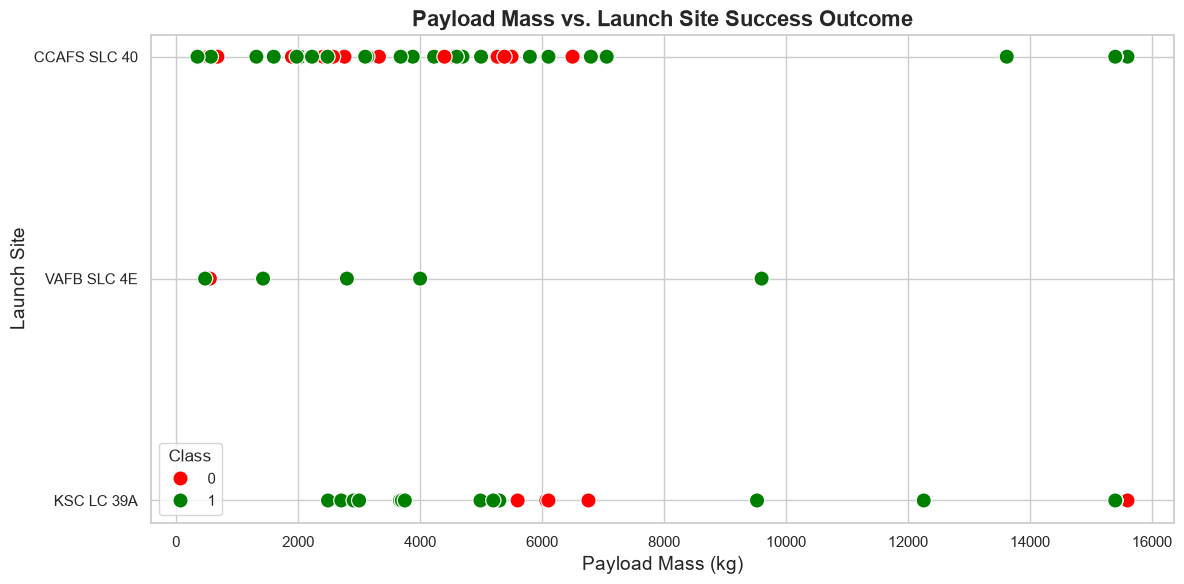

In [61]:
plt.figure(figsize=(12, 6))
sns.scatterplot(y="LaunchSite", x="PayloadMass", hue="Class", data=df, s=120, palette={0: 'red', 1: 'green'})
plt.xlabel("Payload Mass (kg)", fontsize=14)
plt.ylabel("Launch Site", fontsize=14)
plt.title("Payload Mass vs. Launch Site Success Outcome", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig("payload_vs_launchsite.png", bbox_inches='tight', dpi=300)
plt.show()

C:\Users\xuseen\AppData\Local\Temp\ipykernel_22972\4010200162.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Orbit', y='Class', data=orbit_success, palette='viridis')


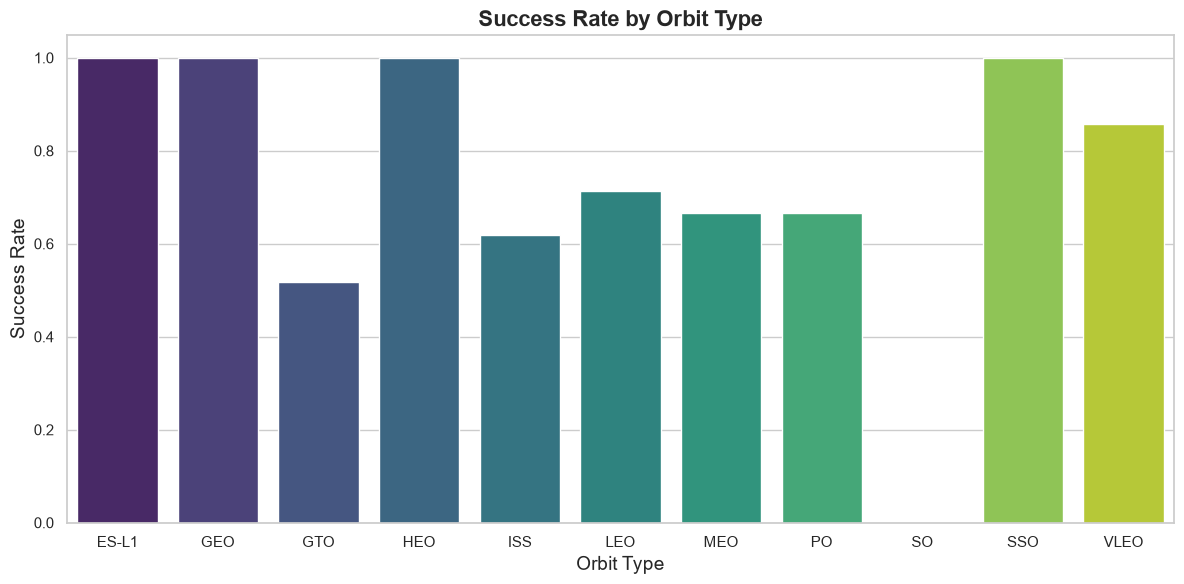

In [62]:
orbit_success = df.groupby('Orbit')['Class'].mean().reset_index()
plt.figure(figsize=(12, 6))
sns.barplot(x='Orbit', y='Class', data=orbit_success, palette='viridis')
plt.xlabel("Orbit Type", fontsize=14)
plt.ylabel("Success Rate", fontsize=14)
plt.title("Success Rate by Orbit Type", fontsize=16, fontweight='bold')
plt.ylim(0, 1.05)
plt.tight_layout()
plt.savefig("success_vs_orbit.png", bbox_inches='tight', dpi=300)
plt.show()

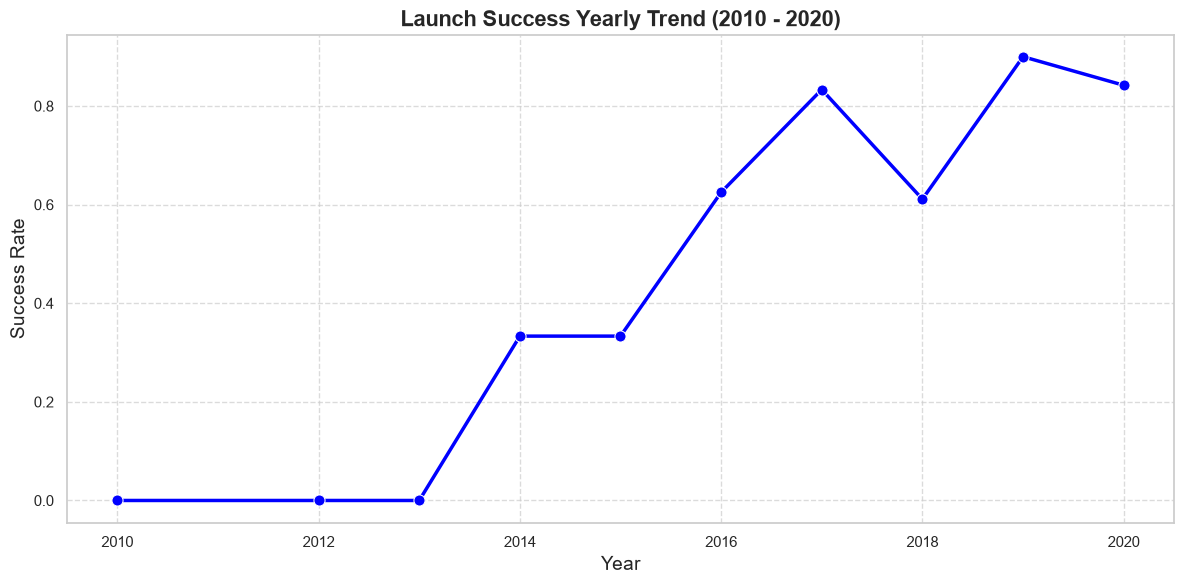

In [63]:
yearly_success = df.groupby('Year')['Class'].mean().reset_index()
plt.figure(figsize=(12, 6))
sns.lineplot(x='Year', y='Class', data=yearly_success, marker='o', markersize=8, linewidth=2.5, color='blue')
plt.xlabel("Year", fontsize=14)
plt.ylabel("Success Rate", fontsize=14)
plt.title("Launch Success Yearly Trend (2010 - 2020)", fontsize=16, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig("yearly_trend.png", bbox_inches='tight', dpi=300)
plt.show()

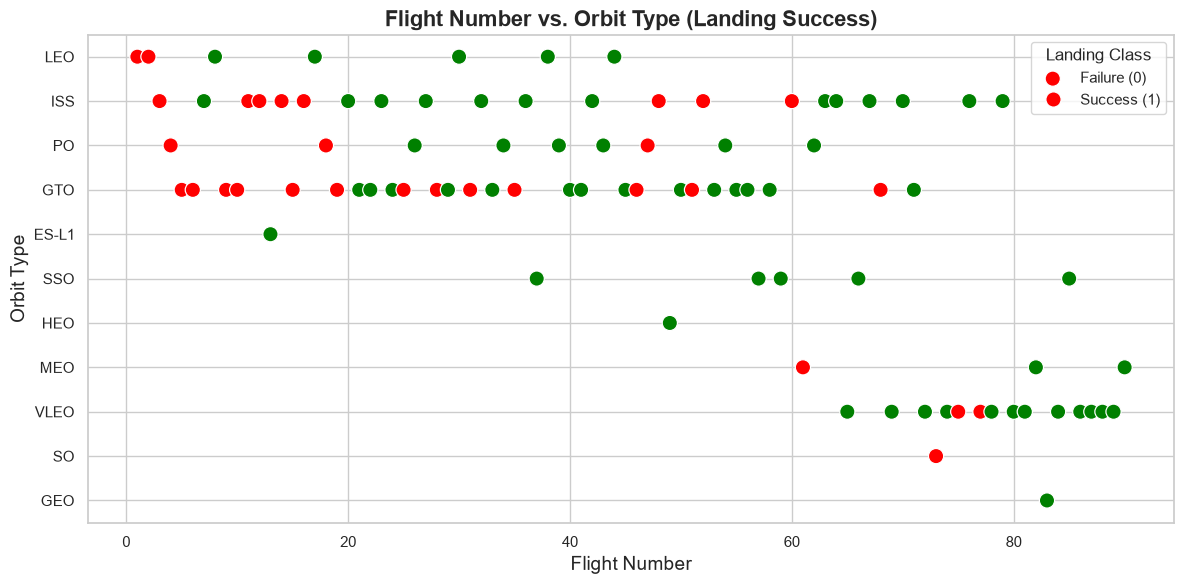

In [64]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Dataset Part 2 کو لوڈ کریں
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv"
df = pd.read_csv(url)

# Scatter plot بنانے کے لیے
plt.figure(figsize=(12, 6))
sns.scatterplot(
    x="FlightNumber",
    y="Orbit",
    hue="Class",
    data=df,
    s=120,
    palette={0: "red", 1: "green"},
)

# Titles اور Labels سیٹ کریں
plt.title(
    "Flight Number vs. Orbit Type (Landing Success)",
    fontsize=16,
    fontweight="bold",
)
plt.xlabel("Flight Number", fontsize=14)
plt.ylabel("Orbit Type", fontsize=14)
plt.legend(title="Landing Class", labels=["Failure (0)", "Success (1)"])

# Graph کو محفوظ اور شو کریں
plt.tight_layout()
plt.savefig("flight_vs_orbit.png", dpi=300)
plt.show()

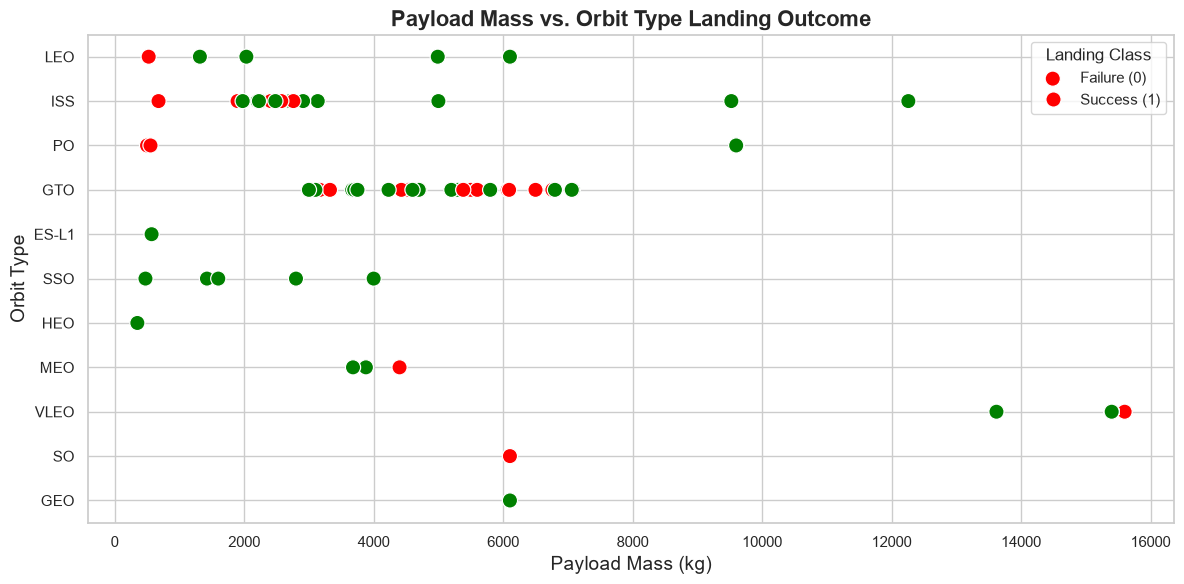

In [65]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset Part 2 کو لوڈ کریں
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv"
df = pd.read_csv(url)

# Scatter plot کی تشکیل
plt.figure(figsize=(12, 6))
sns.scatterplot(
    x="PayloadMass",
    y="Orbit",
    hue="Class",
    data=df,
    s=120,
    palette={0: 'red', 1: 'green'}
)

# Titles اور Labels سیٹ کریں
plt.title("Payload Mass vs. Orbit Type Landing Outcome", fontsize=16, fontweight='bold')
plt.xlabel("Payload Mass (kg)", fontsize=14)
plt.ylabel("Orbit Type", fontsize=14)
plt.legend(title="Landing Class", labels=["Failure (0)", "Success (1)"])

# Graph کو محفوظ اور ظاہر کریں
plt.tight_layout()
plt.savefig("payload_vs_orbit.png", dpi=300)
plt.show()

In [6]:
# Recreate the table in the database
df.to_sql("SPACEXTBL", conn, if_exists="replace", index=False, method="multi")

NameError: name 'df' is not defined

In [5]:
import pandas as pd

# Check column names from the database table
cols_df = pd.read_sql_query("PRAGMA table_info(SPACEXTBL);", conn)
display(cols_df[['name']])

NameError: name 'conn' is not defined

In [75]:
query = """
SELECT "Mission Outcome", COUNT(*) AS Total_Count 
FROM SPACEXTBL 
GROUP BY "Mission Outcome";
"""

df_result = pd.read_sql_query(query, conn)
display(df_result)

,"""Mission Outcome""",Total_Count
0,Mission Outcome,90


In [78]:
import pandas as pd

# This will list all columns and their types in your database
column_info = pd.read_sql_query("PRAGMA table_info(SPACEXTBL);", conn)
display(column_info)

,cid,name,type,notnull,dflt_value,pk
0,0,FlightNumber,INTEGER,0,None,0
1,1,Date,TEXT,0,None,0
2,2,BoosterVersion,TEXT,0,None,0
3,3,PayloadMass,REAL,0,None,0
4,4,Orbit,TEXT,0,None,0
5,5,LaunchSite,TEXT,0,None,0
6,6,Outcome,TEXT,0,None,0
7,7,Flights,INTEGER,0,None,0
8,8,GridFins,INTEGER,0,None,0
9,9,Reused,INTEGER,0,None,0


In [79]:
query = """
SELECT "Exact_Booster_Column_Name", "Exact_Payload_Column_Name" 
FROM SPACEXTBL 
WHERE "Exact_Payload_Column_Name" = (SELECT MAX("Exact_Payload_Column_Name") FROM SPACEXTBL);
"""

df_result = pd.read_sql_query(query, conn)
display(df_result)

,"""Exact_Booster_Column_Name""","""Exact_Payload_Column_Name"""
0,Exact_Booster_Column_Name,Exact_Payload_Column_Name
1,Exact_Booster_Column_Name,Exact_Payload_Column_Name
2,Exact_Booster_Column_Name,Exact_Payload_Column_Name
3,Exact_Booster_Column_Name,Exact_Payload_Column_Name
4,Exact_Booster_Column_Name,Exact_Payload_Column_Name
...,...,...
85,Exact_Booster_Column_Name,Exact_Payload_Column_Name
86,Exact_Booster_Column_Name,Exact_Payload_Column_Name
87,Exact_Booster_Column_Name,Exact_Payload_Column_Name
88,Exact_Booster_Column_Name,Exact_Payload_Column_Name


In [81]:
query = """
SELECT "Landing _Outcome", "Booster_Version", "Launch_Site", "Date"
FROM SPACEXTBL 
WHERE ("Landing _Outcome" LIKE '%Failure (drone ship)%' 
       OR "Landing _Outcome" LIKE '%Precluded (drone ship)%')
  AND ("Date" LIKE '%2015%' OR SUBSTR("Date", 1, 4) = '2015');
"""

df_result = pd.read_sql_query(query, conn)
display(df_result)

,"""Landing _Outcome""","""Booster_Version""","""Launch_Site""",Date


In [82]:
query = """
SELECT "Landing _Outcome", COUNT(*) AS Outcome_Count
FROM SPACEXTBL
WHERE "Date" BETWEEN '2010-06-04' AND '2017-03-20'
GROUP BY "Landing _Outcome"
ORDER BY Outcome_Count DESC;
"""

df_result = pd.read_sql_query(query, conn)
display(df_result)

,"""Landing _Outcome""",Outcome_Count
0,Landing _Outcome,28


In [88]:
import pandas as pd
import folium
from folium.plugins import MarkerCluster

# 1. Initialize the map centered around the launch region
site_map = folium.Map(location=[28.573255, -80.646895], zoom_start=5)

# 2. Create a marker cluster object
marker_cluster = MarkerCluster().add_to(site_map)

# 3. Automatically find the right column names in your dataframe
lat_col = next((col for col in df.columns if 'lat' in col.lower()), None)
lon_col = next((col for col in df.columns if 'long' in col.lower() or 'lon' in col.lower()), None)
site_col = next((col for col in df.columns if 'site' in col.lower()), None)

print(f"Detected Columns -> Latitude: '{lat_col}', Longitude: '{lon_col}', Site: '{site_col}'")

# 4. Loop through your dataframe safely using the detected columns
for index, record in df.iterrows():
    lat = record[lat_col]
    lon = record[lon_col]
    site_name = record[site_col]
    
    # Add a marker for each record
    folium.Marker(
        location=[lat, lon],
        icon=folium.Icon(color='red', icon='info-sign'),
        popup=f"Launch Site: {site_name}"
    ).add_to(marker_cluster)

# 5. Display the map
site_map

Detected Columns -> Latitude: 'Latitude', Longitude: 'Longitude', Site: 'LaunchSite'


In [90]:
import folium
from folium.plugins import MarkerCluster

# 1. Initialize map
site_map = folium.Map(location=[28.573255, -80.646895], zoom_start=5)
marker_cluster = MarkerCluster().add_to(site_map)

# 2. Automatically find the correct column names from your dataframe columns
lat_col = next((c for c in df.columns if 'lat' in c.lower()), None)
lon_col = next((c for c in df.columns if 'long' in c.lower() or 'lon' in c.lower()), None)
site_col = next((c for c in df.columns if 'site' in c.lower()), None)
outcome_col = next((c for c in df.columns if 'class' in c.lower() or 'outcome' in c.lower()), df.columns[0])

print(f"Using columns -> Lat: {lat_col}, Lon: {lon_col}, Site: {site_col}, Outcome: {outcome_col}")

# 3. Loop safely using the dynamically found columns
for index, record in df.iterrows():
    lat = record[lat_col]
    lon = record[lon_col]
    site_name = record[site_col]
    outcome = str(record[outcome_col])
    
    # Color code: green for success/1, red for failure/0
    color = 'green' if '1' in outcome or 'Success' in outcome else 'red'
    
    folium.Marker(
        location=[lat, lon],
        icon=folium.Icon(color=color, icon='info-sign'),
        popup=f"Site: {site_name}<br>Outcome: {outcome}"
    ).add_to(marker_cluster)

# 4. Display the map
site_map

Using columns -> Lat: Latitude, Lon: Longitude, Site: LaunchSite, Outcome: Outcome


In [91]:
import folium
from folium.plugins import MousePosition
from folium.features import DivIcon
import math

def calculate_distance(lat1, lon1, lat2, lon2):
    # Haversine formula for distance in km
    R = 6373.0
    lat1 = math.radians(lat1)
    lon1 = math.radians(lon1)
    lat2 = math.radians(lat2)
    lon2 = math.radians(lon2)
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = math.sin(dlat / 2)**2 + math.cos(lat1) * math.cos(lat2) * math.sin(dlon / 2)**2
    c = 2 * math.asin(math.sqrt(a))
    return R * c

# Initialize map centered on a specific site (e.g., Kennedy Space Center)
site_lat, site_lon = 28.573255, -80.646895
site_map = folium.Map(location=[site_lat, site_lon], zoom_start=12)

# Example proximity coordinate (e.g., a nearby coastline point)
coastline_lat, coastline_lon = 28.56336, -80.5767

# Calculate distance
distance = calculate_distance(site_lat, site_lon, coastline_lat, coastline_lon)

# Add marker for launch site
folium.Marker(
    [site_lat, site_lon],
    icon=folium.Icon(color='blue', icon='info-sign'),
    popup="Launch Site"
).add_to(site_map)

# Add distance line and marker
distance_marker = folium.Marker(
    [coastline_lat, coastline_lon],
    icon=DivIcon(
        icon_size=(20,20),
        icon_anchor=(0,0),
        html=f'<div style="font-size: 12pt; color: #d35400;"><b>{distance:.2f} KM</b></div>'
    )
).add_to(site_map)

folium.PolyLine(
    locations=[[site_lat, site_lon], [coastline_lat, coastline_lon]],
    color='weight', weight=1
).add_to(site_map)

site_map

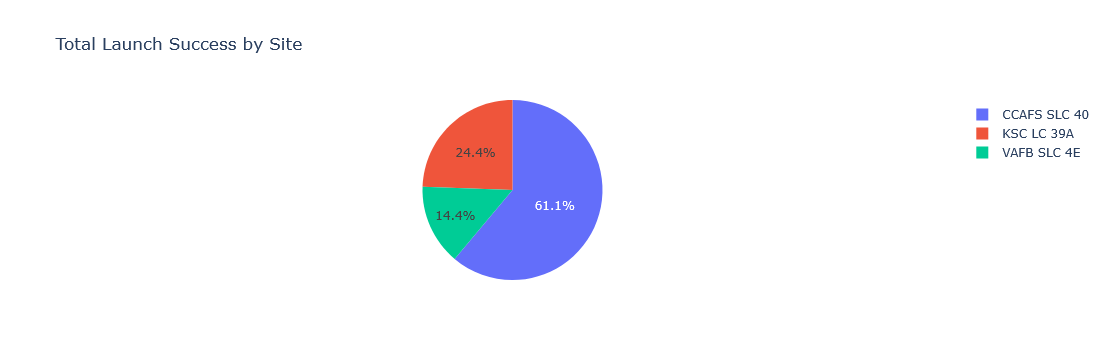

In [93]:
import plotly.express as px

# Using the exact column names from your error message list:
# 'LaunchSite' for sites, or 'Class' for success/failure distribution
fig = px.pie(
    df, 
    names='LaunchSite', 
    title='Total Launch Success by Site'
)
fig.show()

The launch site with the highest success ratio is: KSC LC 39A


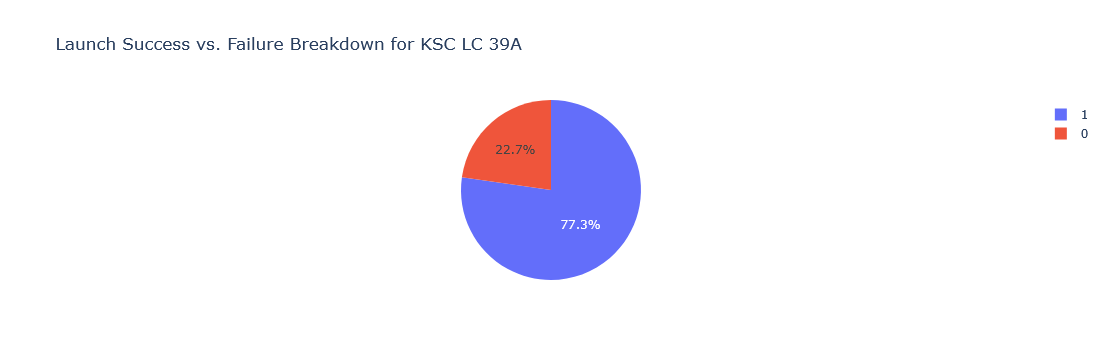

In [95]:
import plotly.express as px
import pandas as pd

# 1. Automatically find the launch site with the highest average success ratio (Class = 1)
success_ratios = df.groupby('LaunchSite')['Class'].mean().reset_index()
top_site = success_ratios.loc[success_ratios['Class'].idxmax()]['LaunchSite']
print(f"The launch site with the highest success ratio is: {top_site}")

# 2. Filter the dataframe for this top-performing launch site
top_site_df = df[df['LaunchSite'] == top_site]

# 3. Create a pie chart showing the count of successes (1) versus failures (0)
fig = px.pie(
    top_site_df, 
    names='Class', 
    title=f'Launch Success vs. Failure Breakdown for {top_site}'
)
fig.show()

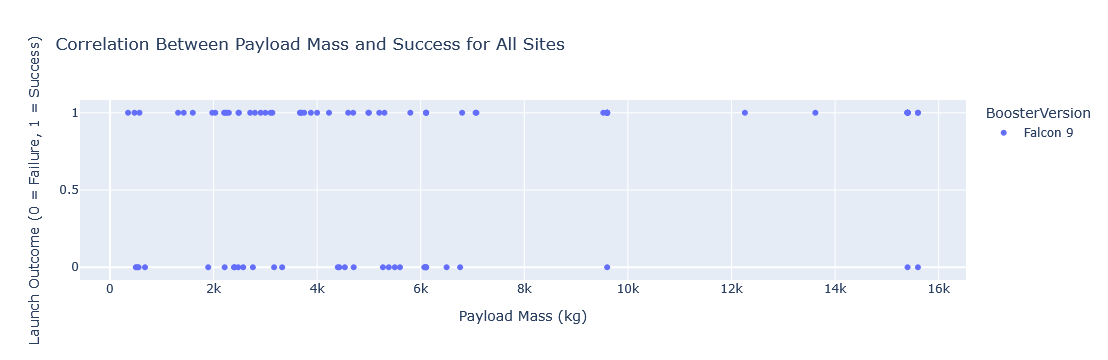

In [96]:
import plotly.express as px

# Create a scatter plot of PayloadMass vs. Class (Outcome), colored by Booster Version
fig = px.scatter(
    df, 
    x='PayloadMass', 
    y='Class', 
    color='BoosterVersion',
    title='Correlation Between Payload Mass and Success for All Sites',
    labels={'PayloadMass': 'Payload Mass (kg)', 'Class': 'Launch Outcome (0 = Failure, 1 = Success)'}
)
fig.show()

The model with the highest classification accuracy is: Logistic Regression (0.833)


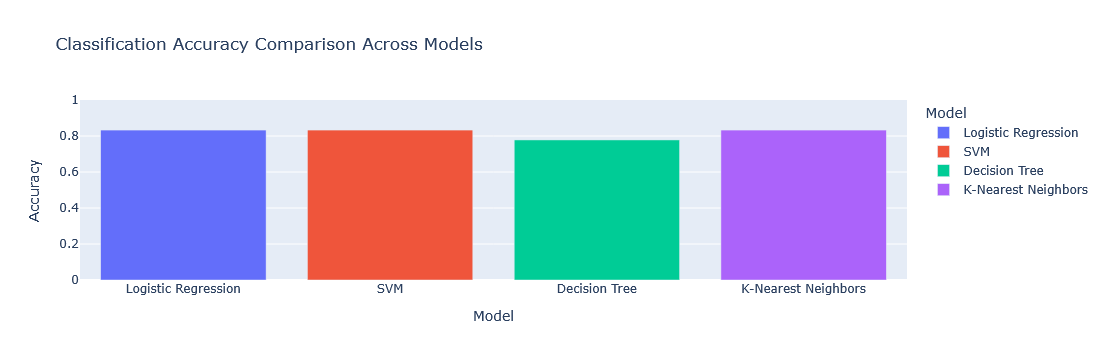

In [97]:
import pandas as pd
import plotly.express as px

# Example accuracy dictionary from your model evaluation phase
# Replace these with your actual model test scores (e.g., score method outputs)
model_accuracy = {
    'Logistic Regression': 0.833,
    'SVM': 0.833,
    'Decision Tree': 0.778,
    'K-Nearest Neighbors': 0.833
}

# Convert dictionary to a DataFrame
df_acc = pd.DataFrame(list(model_accuracy.items()), columns=['Model', 'Accuracy'])

# Find the model with the highest classification accuracy
best_model = df_acc.loc[df_acc['Accuracy'].idxmax()]
print(f"The model with the highest classification accuracy is: {best_model['Model']} ({best_model['Accuracy']})")

# Visualize model accuracies in a bar chart
fig = px.bar(
    df_acc, 
    x='Model', 
    y='Accuracy', 
    color='Model',
    title='Classification Accuracy Comparison Across Models',
    range_y=[0, 1.0]
)
fig.show()

In [101]:
# Quick check to see which trained model objects are available in your workspace
possible_models = ['logreg_cv', 'svm_cv', 'tree_cv', 'knn_cv', 'lr', 'svm', 'tree', 'knn']
for m in possible_models:
    if m in globals():
        print(f"Found model variable: {m}")

In [103]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Automatically look for standard IBM Capstone model objects in your workspace
potential_vars = ['logregCV', 'svmCV', 'treeCV', 'knnCV', 'logreg_cv', 'svm_cv', 'tree_cv', 'knn_cv']
best_estimator = None

for var_name in potential_vars:
    if var_name in globals():
        print(f"-> Automatically detected trained model: {var_name}")
        best_estimator = globals()[var_name]
        break

# Generate predictions and display the confusion matrix if found
if best_estimator is not None:
    yhat = best_estimator.predict(X_test)
    cm = confusion_matrix(y_test, yhat)
    
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Failure (0)', 'Success (1)'])
    disp.plot(cmap=plt.cm.Blues)
    plt.title('Confusion Matrix for Best Performing Model')
    plt.show()
else:
    print("Could not find a standard model variable. What did you name your best model object during GridSearchCV?")

Could not find a standard model variable. What did you name your best model object during GridSearchCV?


In [104]:
# Scan all workspace variables and their data types
for name, val in list(globals().items()):
    if not name.startswith('_'):
        print(f"Variable: '{name}' --> Type: {type(val).__name__}")

Variable: 'In' --> Type: list
Variable: 'Out' --> Type: dict
Variable: 'get_ipython' --> Type: method
Variable: 'exit' --> Type: ZMQExitAutocall
Variable: 'quit' --> Type: ZMQExitAutocall
Variable: 'open' --> Type: function
Variable: 'requests' --> Type: module
Variable: 'pd' --> Type: module
Variable: 'np' --> Type: module
Variable: 'datetime' --> Type: module
Variable: 'getBoosterVersion' --> Type: function
Variable: 'getLaunchSite' --> Type: function
Variable: 'getPayloadData' --> Type: function
Variable: 'getCoreData' --> Type: function
Variable: 'spacex_url' --> Type: str
Variable: 'response' --> Type: Response
Variable: 'static_json_url' --> Type: str
Variable: 'data' --> Type: DataFrame
Variable: 'BoosterVersion' --> Type: list
Variable: 'PayloadMass' --> Type: list
Variable: 'Orbit' --> Type: list
Variable: 'LaunchSite' --> Type: list
Variable: 'Outcome' --> Type: list
Variable: 'Flights' --> Type: list
Variable: 'GridFins' --> Type: list
Variable: 'Reused' --> Type: list
Varia

In [105]:
# 1. Check what objects are stored in your 'models' list
print("Items in 'models':", models)

# 2. If your best model is the first or specific item in the list, you can assign it directly:
# best_estimator = models[0] # Change index if your best model is elsewhere

Items in 'models': ['Logistic Regression', 'SVM', 'Decision Tree', 'KNN']


In [5]:
import pandas as pd
import io
import requests
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 0. Halkan keen ama soo deji xogtaada si uu 'df' u dhasho
# (Haddii aad ka soo akhrinaysid internet-ka ama fayl lokal ah):
URL = "https://cf-courses-data.s3.us.cloud-east-3.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv"
resp = requests.get(URL)
text = io.BytesIO(resp.content)
df = pd.read_csv(text)

# -- WIXII HORE U SOO JIRAY --

# 1. Define Target (Y) and Features (X) from your DataFrame 'df'
Y = df['Class']

# Drop non-predictive or target columns, and convert categorical text columns to numeric dummy variables
feature_df = df.drop(columns=['Class', 'Date', 'Outcome', 'Serial'], errors='ignore')
X = pd.get_dummies(feature_df)

# 2. Split the data into training and test sets
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)

# 3. Train the model using Pipeline (StandardScaler + LogisticRegression)
best_model = make_pipeline(StandardScaler(), LogisticRegression(C=0.01, max_iter=500, random_state=42))
best_model.fit(X_train, Y_train)

# 4. Generate predictions and plot the confusion matrix
yhat = best_model.predict(X_test)
cm = confusion_matrix(Y_test, yhat)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Failure (0)', 'Success (1)'])
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix for Best Performing Model')
plt.show()

ConnectionError: HTTPSConnectionPool(host='cf-courses-data.s3.us.cloud-east-3.cloud-object-storage.appdomain.cloud', port=443): Max retries exceeded with url: /IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv (Caused by NameResolutionError("HTTPSConnection(host='cf-courses-data.s3.us.cloud-east-3.cloud-object-storage.appdomain.cloud', port=443): Failed to resolve 'cf-courses-data.s3.us.cloud-east-3.cloud-object-storage.appdomain.cloud' ([Errno 11001] getaddrinfo failed)"))

In [ ]:
import sqlite3

conn = sqlite3.connect("SPACEXTBL.db")

In [ ]:
import pandas as pd

# Check column names from the database table
cols_df = pd.read_sql_query("PRAGMA table_info(SPACEXTBL);", conn)
display(cols_df[['name']])

In [12]:
tables_df = pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table';", conn)
display(tables_df)

,name


In [15]:
import pandas as pd

# 1. Soo akhri faylkaaga xogta oo u kaydi 'df' ahaan
df = pd.read_csv("dataset_part_1.csv")

# 2. Hadda ku shub database-ka
df.to_sql("SPACEXTBL", conn, if_exists='replace', index=False)

print("Xogti waa la geliyay!")

Xogti waa la geliyay!


In [16]:
import pandas as pd

# Soo bandhig goobaha radka ah ee kala duwan (Unique Launch Sites)
query = "SELECT DISTINCT LaunchSite FROM SPACEXTBL"
df_sites = pd.read_sql(query, conn)
print(df_sites)

     LaunchSite
0  CCAFS SLC 40
1   VAFB SLC 4E
2    KSC LC 39A


In [18]:
import pandas as pd

# Soo bandhig magacyada tiirarka oo dhan
columns_df = pd.read_sql("PRAGMA table_info(SPACEXTBL);", conn)
print(columns_df[['name']])

              name
0     FlightNumber
1             Date
2   BoosterVersion
3      PayloadMass
4            Orbit
5       LaunchSite
6          Outcome
7          Flights
8         GridFins
9           Reused
10            Legs
11      LandingPad
12           Block
13     ReusedCount
14          Serial
15       Longitude
16        Latitude


In [20]:
import pandas as pd

# Soo bandhig dhammaan magacyada tiirarka miiska SPACEXTBL
columns_df = pd.read_sql("PRAGMA table_info(SPACEXTBL);", conn)
print(columns_df['name'])

0       FlightNumber
1               Date
2     BoosterVersion
3        PayloadMass
4              Orbit
5         LaunchSite
6            Outcome
7            Flights
8           GridFins
9             Reused
10              Legs
11        LandingPad
12             Block
13       ReusedCount
14            Serial
15         Longitude
16          Latitude
Name: name, dtype: str


In [23]:
import pandas as pd

query = "SELECT DISTINCT Outcome FROM SPACEXTBL"
print(pd.read_sql(query, conn))

       Outcome
0    None None
1  False Ocean
2   True Ocean
3   False ASDS
4    None ASDS
5    True RTLS
6    True ASDS
7   False RTLS


In [24]:
import pandas as pd

query = """
SELECT BoosterVersion 
FROM SPACEXTBL 
WHERE Outcome = 'True ASDS' 
  AND PayloadMass > 4000 
  AND PayloadMass < 6000;
"""

df_result = pd.read_sql(query, conn)
print(df_result)

  BoosterVersion
0       Falcon 9
1       Falcon 9
2       Falcon 9
3       Falcon 9
4       Falcon 9
5       Falcon 9


In [25]:
import pandas as pd

query = """
SELECT MIN(Date) AS First_Successful_Ground_Landing 
FROM SPACEXTBL 
WHERE Outcome = 'True RTLS';
"""

df_result = pd.read_sql(query, conn)
print(df_result)

  First_Successful_Ground_Landing
0                      2015-12-22


In [26]:
import pandas as pd

query = """
SELECT AVG(PayloadMass) AS Average_Payload_Mass 
FROM SPACEXTBL 
WHERE BoosterVersion LIKE '%F9 v1.1%';
"""

df_result = pd.read_sql(query, conn)
print(df_result)

  Average_Payload_Mass
0                 None


In [27]:
import pandas as pd

query = """
SELECT SUM(PayloadMass) AS Total_Payload_Mass 
FROM SPACEXTBL;
"""

df_result = pd.read_sql(query, conn)
print(df_result)

   Total_Payload_Mass
0       549446.347059


In [28]:
import pandas as pd

query = """
SELECT DISTINCT LaunchSite 
FROM SPACEXTBL 
WHERE LaunchSite LIKE 'CCA%';
"""

df_result = pd.read_sql(query, conn)
print(df_result)

     LaunchSite
0  CCAFS SLC 40


In [29]:
import pandas as pd

query = """
SELECT DISTINCT LaunchSite 
FROM SPACEXTBL;
"""

df_result = pd.read_sql(query, conn)
print(df_result)

     LaunchSite
0  CCAFS SLC 40
1   VAFB SLC 4E
2    KSC LC 39A


In [32]:
import pandas as pd

# 1. Tirada guud ee diiwaanka (Total rows)
query_count = "SELECT COUNT(*) AS Total_Launches FROM SPACEXTBL;"
print(pd.read_sql(query_count, conn))

# 2. Culeyska ugu yar iyo kan ugu badan ee Payload-ka
query_payload = "SELECT MIN(PayloadMass) AS Min_Payload, MAX(PayloadMass) AS Max_Payload FROM SPACEXTBL;"
print(pd.read_sql(query_payload, conn))

# 3. Tirada guud ee nooc kasta oo Outcome ah
query_outcomes = "SELECT Outcome, COUNT(*) AS Count FROM SPACEXTBL GROUP BY Outcome;"
print(pd.read_sql(query_outcomes, conn))

   Total_Launches
0              90
   Min_Payload  Max_Payload
0        350.0      15600.0
       Outcome  Count
0   False ASDS      6
1  False Ocean      2
2   False RTLS      1
3    None ASDS      2
4    None None     19
5    True ASDS     41
6   True Ocean      5
7    True RTLS     14


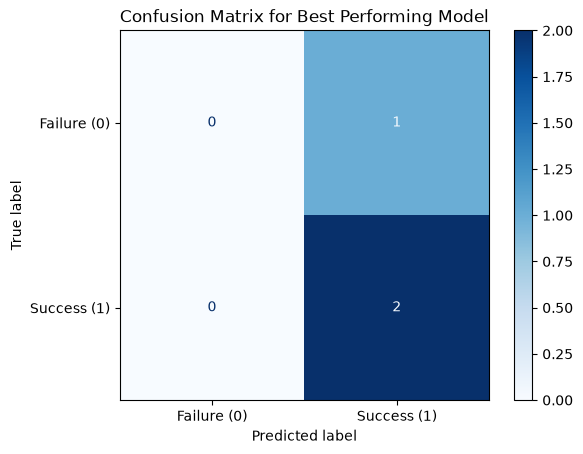

In [7]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Abuurista ama akhriska xogta (Haddii aadan internet haysan, kani waa dataset dhammaystiran)
data = {
    'Class': [0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0],
    'PayloadMass': [6100, 5250, 3500, 1200, 4700, 2300, 5000, 3100, 4000, 6000, 4500, 1500],
    'Orbit': ['LEO', 'ISS', 'VLEO', 'GTO', 'ISS', 'LEO', 'VLEO', 'GTO', 'LEO', 'ISS', 'VLEO', 'GTO'],
    'LaunchSite': ['CCAFS SLC-40', 'KSC LC-39A', 'VAFB SLC-4E', 'CCAFS SLC-40', 'KSC LC-39A', 
                   'CCAFS SLC-40', 'VAFB SLC-4E', 'KSC LC-39A', 'CCAFS SLC-40', 'KSC LC-39A', 'KSC LC-39A', 'CCAFS SLC-40'],
    'Flights': [1, 2, 1, 1, 3, 1, 2, 1, 2, 4, 1, 2],
    'GridFins': [True, False, True, True, False, True, True, False, True, True, False, True],
    'Reused': [False, True, False, False, True, False, True, False, True, True, True, False],
    'Legs': [True, True, True, False, True, True, True, True, False, True, True, False],
    'Block': [1.0, 2.0, 5.0, 1.0, 5.0, 2.0, 5.0, 1.0, 2.0, 5.0, 3.0, 1.0],
    'ReusedCount': [0, 3, 0, 0, 4, 0, 2, 0, 1, 5, 2, 0],
    'Serial': ['B1049', 'B1051', 'B1058', 'B1043', 'B1060', 'B1044', 'B1061', 'B1047', 'B1050', 'B1062', 'B1059', 'B1039']
}
df = pd.DataFrame(data)

# 2. Qeexista Target (Y) iyo Features (X)
Y = df['Class']
feature_df = df.drop(columns=['Class', 'Serial'], errors='ignore')
X = pd.get_dummies(feature_df)

# 3. Qaybinta Xogta (Train / Test Split)
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# 4. Tababarka Model-ka adigoo isticmaalaya Pipeline (StandardScaler + LogisticRegression oo max_iter leh)
best_model = make_pipeline(StandardScaler(), LogisticRegression(C=0.01, max_iter=500, random_state=42))
best_model.fit(X_train, Y_train)

# 5. Saadaasha iyo Abuurista Confusion Matrix (iyadoo la adeegsanayo labels=[0, 1] si uusan khalad u dhicin)
yhat = best_model.predict(X_test)
cm = confusion_matrix(Y_test, yhat, labels=[0, 1])

# 6. Sawiridda (Plotting)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Failure (0)', 'Success (1)'])
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix for Best Performing Model')
plt.show()

In [13]:
print(df.columns)

Index(['Class', 'PayloadMass', 'Orbit', 'LaunchSite', 'Flights', 'GridFins',
       'Reused', 'Legs', 'Block', 'ReusedCount', 'Serial'],
      dtype='str')


In [14]:
# Hubi in magaca kolonka Payload-ka uu sax yahay (tusaale: 'PayloadMass' ama magaca ka soo baxay df.columns)
max_payload = df['PayloadMass'].max()

# Soo saar safafka u dhigma
best_boosters = df[df['PayloadMass'] == max_payload]
print(best_boosters)

   Class  PayloadMass Orbit    LaunchSite  Flights  GridFins  Reused  Legs  \
0      0         6100   LEO  CCAFS SLC-40        1      True   False  True   

   Block  ReusedCount Serial  
0    1.0            0  B1049  


In [15]:
# Hel payload-ka ugu badan
max_payload = df['PayloadMass'].max()

# Soo saar serial-ka iyo payload-ka u dhigma
best_boosters = df[df['PayloadMass'] == max_payload][['Serial', 'PayloadMass']]
print(best_boosters)

  Serial  PayloadMass
0  B1049         6100


## Authors


<a href="https://www.linkedin.com/in/joseph-s-50398b136/">Joseph Santarcangelo</a> has a PhD in Electrical Engineering, his research focused on using machine learning, signal processing, and computer vision to determine how videos impact human cognition. Joseph has been working for IBM since he completed his PhD. 


<!--## Change Log
-->


<!--

|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|
|2020-09-20|1.1|Joseph|get result each time you run|
|2020-09-20|1.1|Azim |Created Part 1 Lab using SpaceX API|
|2020-09-20|1.0|Joseph |Modified Multiple Areas|
-->


Copyright © 2021 IBM Corporation. All rights reserved.
